In [2]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


In [3]:

# --- Step 1: Generate noisy data ---
np.random.seed(1)

area = np.array([50, 65, 70, 85, 100, 120, 140, 160, 180, 200, 90, 110, 130, 150, 75])
noise = np.random.normal(0, 3000, size=len(area))
price = 300 * area + noise


df = pd.DataFrame({'area': area, 'price': price})

X = df[['area']]
y = df['price']

In [4]:
# --- Step 2: Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train model ---
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (θ0):", model.intercept_)
print("Slope (θ1):", model.coef_[0])

Intercept (θ0): 66.70687412335974
Slope (θ1): 298.4092185229851


In [5]:
# --- Step 4: Predict and evaluate ---
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nLow noise (std=3000):")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Low noise (std=3000):
MSE: 20329767.63
MAE: 3818.22
RMSE: 4508.85


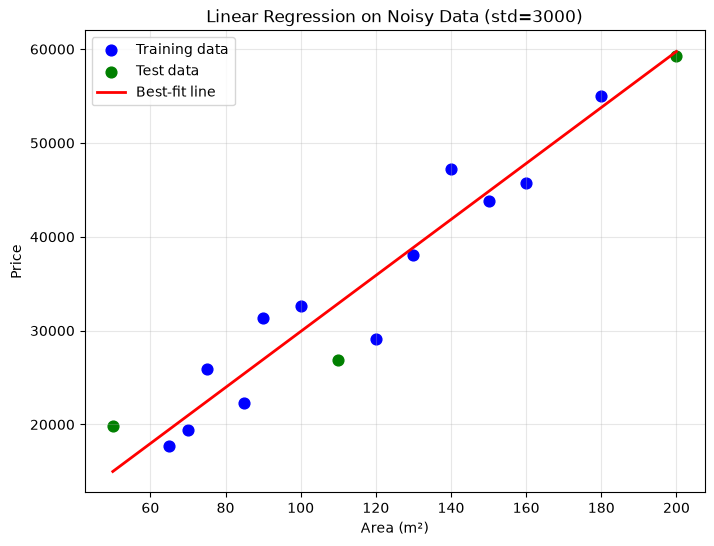

In [12]:
# --- Step 5: Plot ---
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data', s=60)
plt.scatter(X_test, y_test, color='green', label='Test data', s=60)
plt.plot(X.sort_values('area'), model.predict(X.sort_values('area')), color='red', linewidth=2, label='Best-fit line')
plt.xlabel('Area (m²)')
plt.ylabel('Price')
plt.title('Linear Regression on Noisy Data (std=3000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# plt.savefig('/mnt/user-data/outputs/noisy_low.png', dpi=150, bbox_inches='tight')
plt.close()


High noise (std=10000):
Intercept (θ0): -9856.01
Slope (θ1): 435.18
RMSE: 19070.19


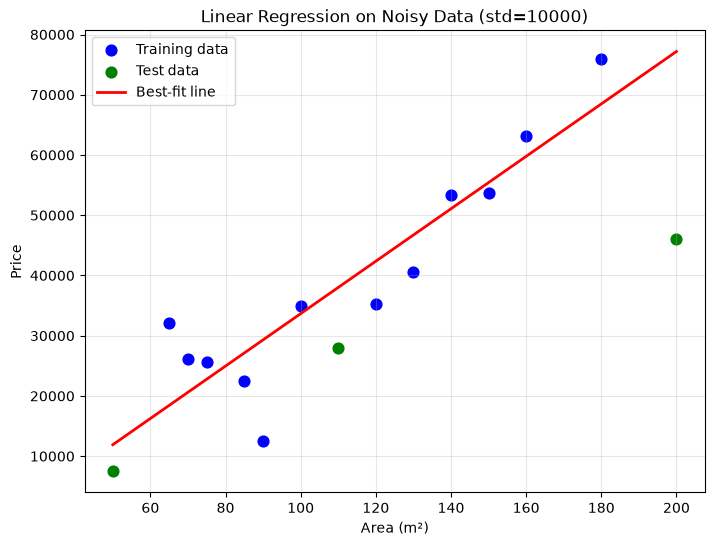

In [11]:
# --- Step 6: Repeat with higher noise ---
noise_high = np.random.normal(0, 10000, size=len(area))
price_high = 300 * area + noise_high

df_high = pd.DataFrame({'area': area, 'price': price_high})
X_high = df_high[['area']]
y_high = df_high['price']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_high, y_high, test_size=0.2, random_state=42)

model_high = LinearRegression()
model_high.fit(X_train_h, y_train_h)

y_pred_high = model_high.predict(X_test_h)
mse_high = mean_squared_error(y_test_h, y_pred_high)
rmse_high = np.sqrt(mse_high)

print(f"\nHigh noise (std=10000):")
print(f"Intercept (θ0): {model_high.intercept_:.2f}")
print(f"Slope (θ1): {model_high.coef_[0]:.2f}")
print(f"RMSE: {rmse_high:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_train_h, y_train_h, color='blue', label='Training data', s=60)
plt.scatter(X_test_h, y_test_h, color='green', label='Test data', s=60)
plt.plot(X_high.sort_values('area'), model_high.predict(X_high.sort_values('area')), color='red', linewidth=2, label='Best-fit line')
plt.xlabel('Area (m²)')
plt.ylabel('Price')
plt.title('Linear Regression on Noisy Data (std=10000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# plt.savefig('/mnt/user-data/outputs/noisy_high.png', dpi=150, bbox_inches='tight')
plt.close()